In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import silhouette_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score

# Set professional styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Load dataset
file_path = r"C:\Users\ASUS\Documents\Personal Things\Project\Customer Segmentation & Churn Analysis Project\Data\Customer Transaction Data.csv"
df = pd.read_csv(file_path)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149365 entries, 0 to 149364
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   149365 non-null  int64  
 1   InvoiceNo    149365 non-null  int64  
 2   StockCode    149365 non-null  object 
 3   Description  149365 non-null  object 
 4   Quantity     149365 non-null  int64  
 5   InvoiceDate  149365 non-null  object 
 6   UnitPrice    149365 non-null  float64
 7   CustomerID   149365 non-null  float64
 8   Country      149365 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 10.3+ MB


In [2]:
# Chuyển đổi cột 'InvoiceDate' sang dạng datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
# Tạo biến TotalPrice (tổng tiền)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

RFM STATISTICS
         CustomerID      Recency    Frequency       Monetary
count   2748.000000  2748.000000  2748.000000    2748.000000
mean   15259.984716    50.899927     2.661572    1287.511479
std     1721.121705    44.136860     3.848291    5210.184888
min    12347.000000     1.000000     1.000000       2.900000
25%    13768.500000    12.000000     1.000000     261.817500
50%    15240.500000    37.000000     2.000000     523.895000
75%    16730.250000    83.000000     3.000000    1103.417500
max    18287.000000   153.000000    88.000000  133683.040000


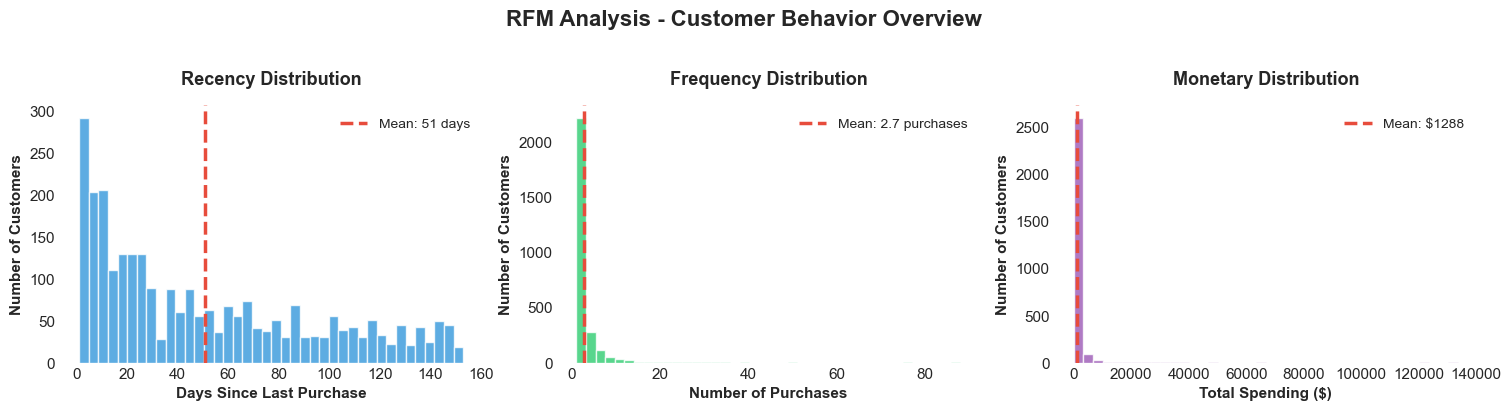

In [3]:
# Snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
# Tạo bảng RFM
rfm = (
    df.groupby('CustomerID')
      .agg({
          'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
          'InvoiceNo': 'nunique',
          'TotalPrice': 'sum'
      })
      .reset_index()
)

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM STATISTICS")
print(rfm.describe())

rfm.head()

# RFM Distribution Plots
fig = plt.figure(figsize=(15, 4))

# Recency
plt.subplot(1, 3, 1)
plt.hist(rfm['Recency'], bins=40, color='#3498db', alpha=0.8, edgecolor='white')
plt.axvline(rfm['Recency'].mean(), color='#e74c3c', linestyle='--', linewidth=2.5, 
           label=f'Mean: {rfm["Recency"].mean():.0f} days')
plt.xlabel('Days Since Last Purchase', fontsize=11, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=11, fontweight='bold')
plt.title('Recency Distribution', fontsize=13, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Frequency
plt.subplot(1, 3, 2)
plt.hist(rfm['Frequency'], bins=40, color='#2ecc71', alpha=0.8, edgecolor='white')
plt.axvline(rfm['Frequency'].mean(), color='#e74c3c', linestyle='--', linewidth=2.5,
           label=f'Mean: {rfm["Frequency"].mean():.1f} purchases')
plt.xlabel('Number of Purchases', fontsize=11, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=11, fontweight='bold')
plt.title('Frequency Distribution', fontsize=13, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Monetary
plt.subplot(1, 3, 3)
plt.hist(rfm['Monetary'], bins=40, color='#9b59b6', alpha=0.8, edgecolor='white')
plt.axvline(rfm['Monetary'].mean(), color='#e74c3c', linestyle='--', linewidth=2.5,
           label=f'Mean: ${rfm["Monetary"].mean():.0f}')
plt.xlabel('Total Spending ($)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=11, fontweight='bold')
plt.title('Monetary Distribution', fontsize=13, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('RFM Analysis - Customer Behavior Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

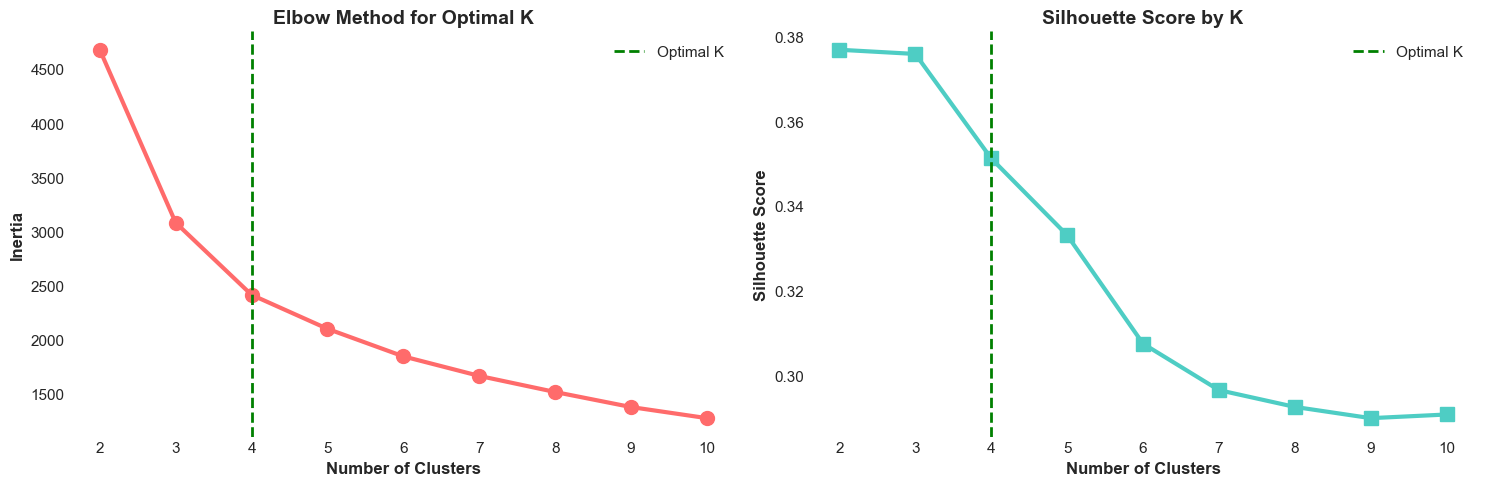


🎯 Optimal K with Silhouette Score: 0.351


In [4]:
# Log-transform và chuẩn hóa
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_features['Frequency'] = np.log1p(rfm_features['Frequency'])
rfm_features['Monetary'] = np.log1p(rfm_features['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Elbow method với Silhouette Score
inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
ax1.plot(range(2, 11), inertia, marker='o', linewidth=3, markersize=10, color='#FF6B6B')
ax1.set_xlabel("Number of Clusters", fontweight='bold')
ax1.set_ylabel("Inertia", fontweight='bold')
ax1.set_title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=4, color='green', linestyle='--', linewidth=2, label='Optimal K')
ax1.legend()

# Silhouette score
ax2.plot(range(2, 11), silhouette_scores, marker='s', linewidth=3, markersize=10, color='#4ECDC4')
ax2.set_xlabel("Number of Clusters", fontweight='bold')
ax2.set_ylabel("Silhouette Score", fontweight='bold')
ax2.set_title("Silhouette Score by K", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=4, color='green', linestyle='--', linewidth=2, label='Optimal K')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n🎯 Optimal K with Silhouette Score: {silhouette_scores[2]:.3f}")

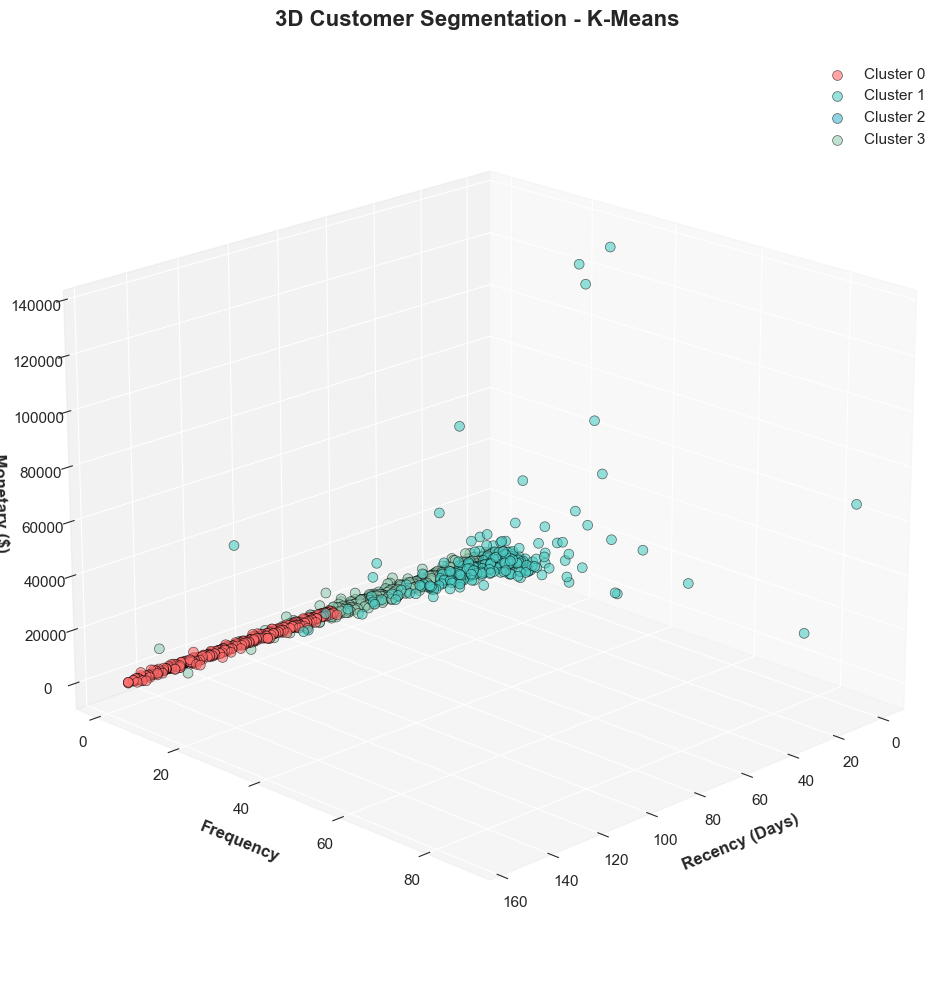

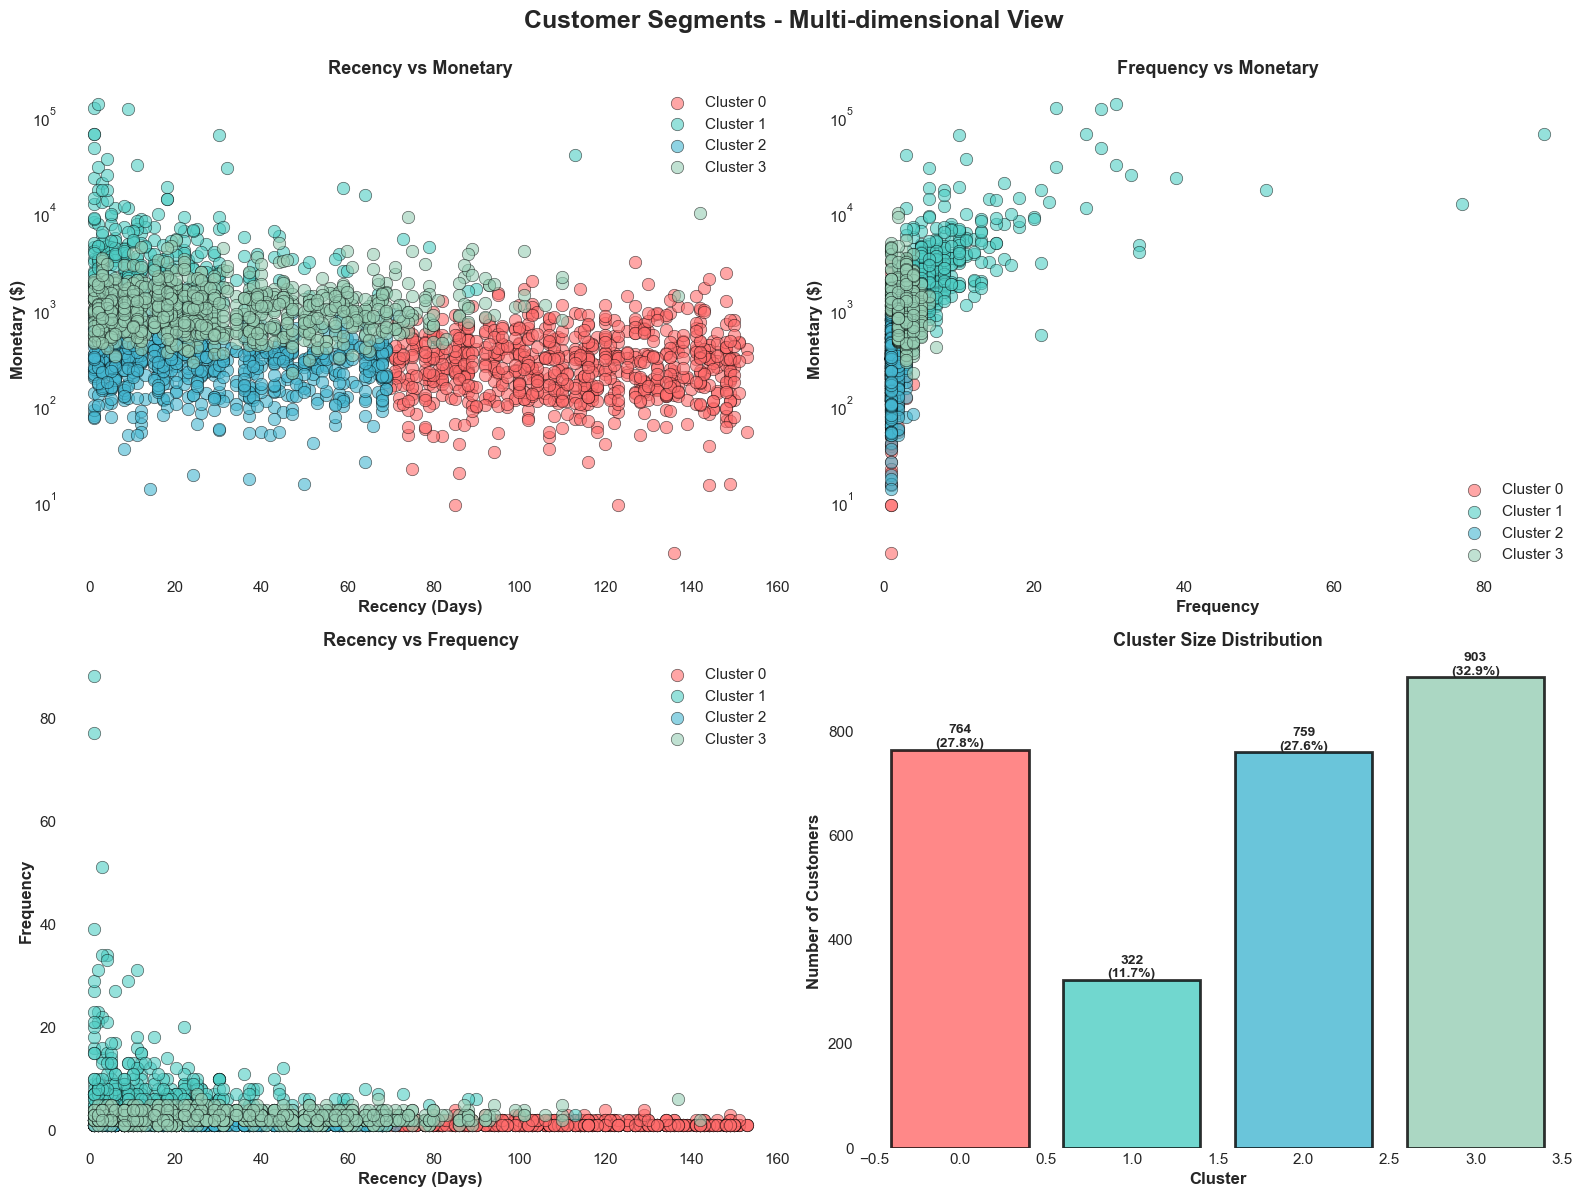

         Recency_mean  Recency_median  Recency_std  Frequency_mean  \
Cluster                                                              
0              111.60           111.0        23.28            1.21   
1               15.93            11.0        16.18            9.26   
2               28.32            24.0        21.10            1.23   
3               31.00            24.0        24.99            2.74   

         Frequency_median  Frequency_std  Monetary_mean  Monetary_median  \
Cluster                                                                    
0                     1.0           0.47         344.06           265.00   
1                     7.0           8.33        6187.22          2799.48   
2                     1.0           0.46         324.99           303.80   
3                     3.0           1.00        1147.58           968.07   

         Monetary_std  Monetary_sum  Customer_Count  Revenue_Contribution_%  
Cluster                                     

In [5]:
# Phân cụm Kmeans với k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 3D Visualization
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors_3d = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        c=colors_3d[cluster],
        label=f'Cluster {cluster}',
        s=50,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

ax.set_xlabel('\nRecency (Days)', fontweight='bold', fontsize=12)
ax.set_ylabel('\nFrequency', fontweight='bold', fontsize=12)
ax.set_zlabel('\nMonetary ($)', fontweight='bold', fontsize=12)
ax.set_title('3D Customer Segmentation - K-Means', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11)
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

# 2D Multi-view
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Segments - Multi-dimensional View', fontsize=18, fontweight='bold', y=0.995)

colors_cluster = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Recency vs Monetary
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[0, 0].scatter(cluster_data['Recency'], cluster_data['Monetary'],
                      c=colors_cluster[cluster], label=f'Cluster {cluster}',
                      s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Recency (Days)', fontweight='bold')
axes[0, 0].set_ylabel('Monetary ($)', fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Recency vs Monetary', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Frequency vs Monetary
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[0, 1].scatter(cluster_data['Frequency'], cluster_data['Monetary'],
                      c=colors_cluster[cluster], label=f'Cluster {cluster}',
                      s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Frequency', fontweight='bold')
axes[0, 1].set_ylabel('Monetary ($)', fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Frequency vs Monetary', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Recency vs Frequency
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[1, 0].scatter(cluster_data['Recency'], cluster_data['Frequency'],
                      c=colors_cluster[cluster], label=f'Cluster {cluster}',
                      s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Recency (Days)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Recency vs Frequency', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Cluster Distribution
cluster_counts = rfm['Cluster'].value_counts().sort_index()
bars = axes[1, 1].bar(cluster_counts.index, cluster_counts.values,
                      color=colors_cluster, edgecolor='black', linewidth=2, alpha=0.8)
axes[1, 1].set_xlabel('Cluster', fontweight='bold')
axes[1, 1].set_ylabel('Number of Customers', fontweight='bold')
axes[1, 1].set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height):,}\n({height/len(rfm)*100:.1f}%)',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Cluster Profiling
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median', 'std'],
    'Frequency': ['mean', 'median', 'std'],
    'Monetary': ['mean', 'median', 'std', 'sum'],
    'CustomerID': 'count'
}).round(2)

cluster_profile.columns = ['_'.join(col).strip() for col in cluster_profile.columns.values]
cluster_profile = cluster_profile.rename(columns={'CustomerID_count': 'Customer_Count'})
cluster_profile['Revenue_Contribution_%'] = (
    cluster_profile['Monetary_sum'] / cluster_profile['Monetary_sum'].sum() * 100
).round(2)

print(cluster_profile)

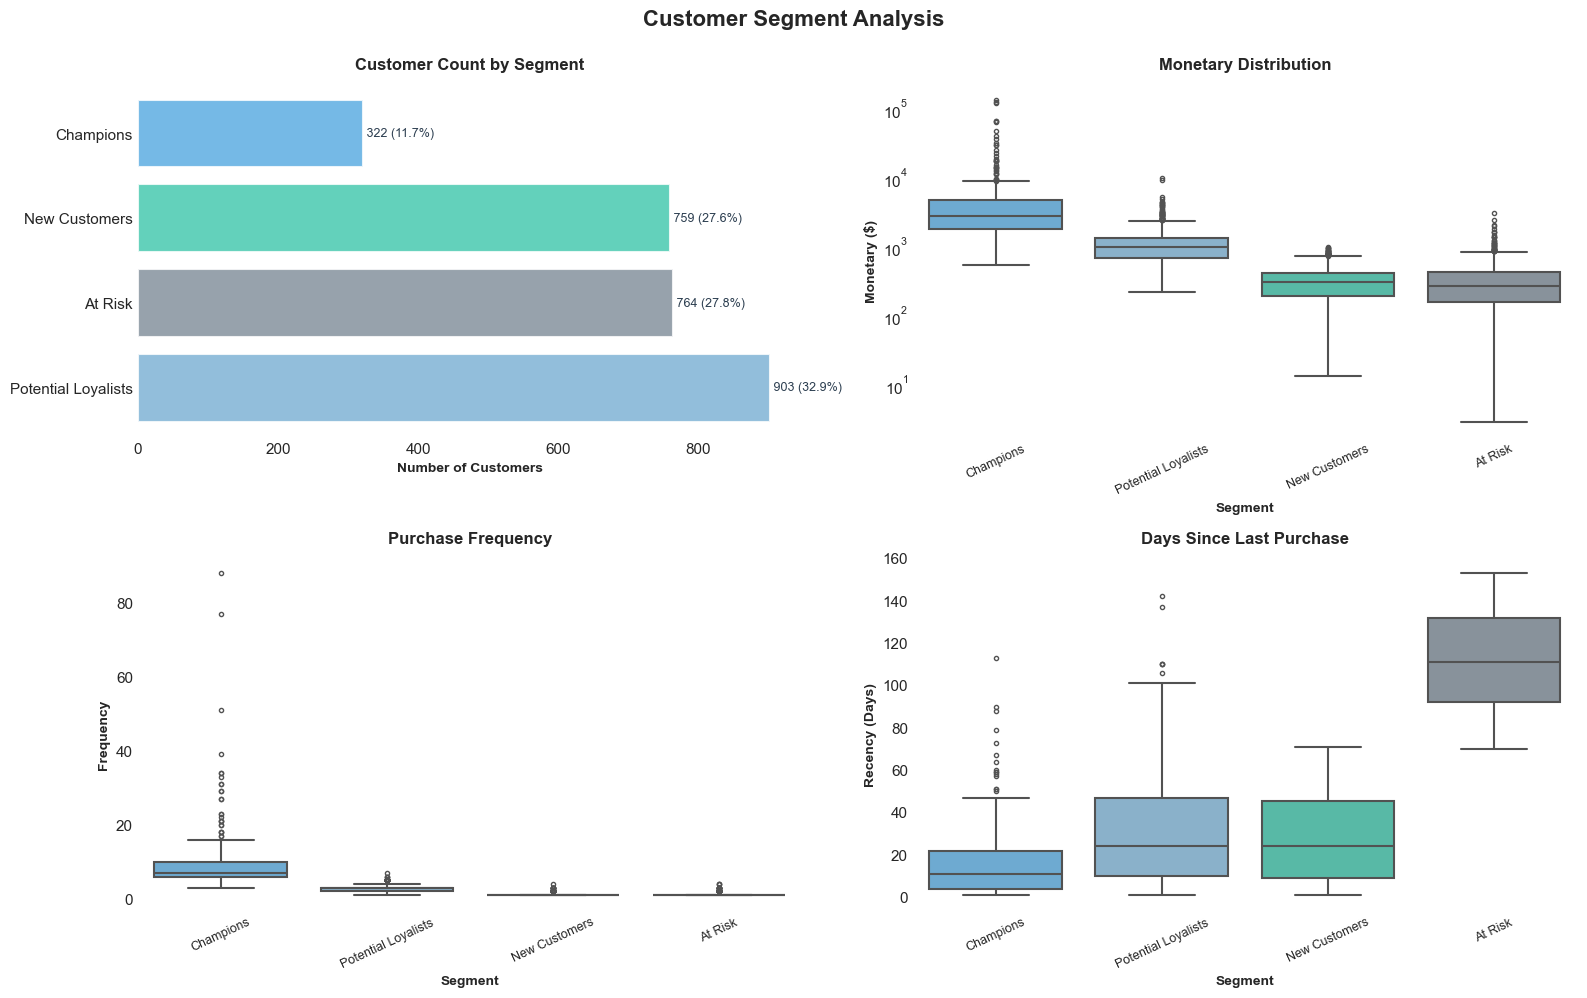

                     Count  Recency_mean  Recency_median  Frequency_mean  \
Segment                                                                    
At Risk                764        111.60           111.0            1.21   
Champions              322         15.93            11.0            9.26   
New Customers          759         28.32            24.0            1.23   
Potential Loyalists    903         31.00            24.0            2.74   

                     Frequency_median  Monetary_mean  Monetary_median  \
Segment                                                                 
At Risk                           1.0         344.06           265.00   
Champions                         7.0        6187.22          2799.48   
New Customers                     1.0         324.99           303.80   
Potential Loyalists               3.0        1147.58           968.07   

                     Monetary_sum  Revenue_Share_%  
Segment                                            

In [6]:
cluster_map = {
    0: 'At Risk',
    1: 'Champions',
    2: 'New Customers',
    3: 'Potential Loyalists'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

# Segment Analysis - Cool Color Palette
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold', y=0.995)

segment_colors = {
    'Champions': '#5DADE2',      # Soft Blue
    'At Risk': '#85929E',         # Cool Gray
    'New Customers': '#48C9B0',   # Teal
    'Potential Loyalists': '#7FB3D5'  # Light Blue
}

# Customer Count by Segment
segment_counts = rfm['Segment'].value_counts()
bars = axes[0, 0].barh(segment_counts.index, segment_counts.values,
                       color=[segment_colors.get(seg, '#BDC3C7') for seg in segment_counts.index],
                       edgecolor='white', linewidth=1.5, alpha=0.85)
axes[0, 0].set_xlabel('Number of Customers', fontsize=10, fontweight='bold')
axes[0, 0].set_title('Customer Count by Segment', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].grid(True, alpha=0.2, axis='x', linestyle='--')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[0, 0].text(width, bar.get_y() + bar.get_height()/2.,
                   f' {int(width):,} ({width/len(rfm)*100:.1f}%)',
                   ha='left', va='center', fontsize=9, color='#2C3E50')

# Monetary by Segment
segment_order = rfm.groupby('Segment')['Monetary'].median().sort_values(ascending=False).index
sns.boxplot(data=rfm, x='Segment', y='Monetary', order=segment_order,
           palette=[segment_colors.get(seg, '#BDC3C7') for seg in segment_order],
           ax=axes[0, 1], linewidth=1.5, fliersize=3)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Segment', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Monetary ($)', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Monetary Distribution', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].tick_params(axis='x', rotation=25, labelsize=9)
axes[0, 1].grid(True, alpha=0.2, axis='y', linestyle='--')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Frequency by Segment
sns.boxplot(data=rfm, x='Segment', y='Frequency', order=segment_order,
           palette=[segment_colors.get(seg, '#BDC3C7') for seg in segment_order],
           ax=axes[1, 0], linewidth=1.5, fliersize=3)
axes[1, 0].set_xlabel('Segment', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Purchase Frequency', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].tick_params(axis='x', rotation=25, labelsize=9)
axes[1, 0].grid(True, alpha=0.2, axis='y', linestyle='--')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Recency by Segment  
sns.boxplot(data=rfm, x='Segment', y='Recency', order=segment_order,
           palette=[segment_colors.get(seg, '#BDC3C7') for seg in segment_order],
           ax=axes[1, 1], linewidth=1.5, fliersize=3)
axes[1, 1].set_xlabel('Segment', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('Recency (Days)', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Days Since Last Purchase', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].tick_params(axis='x', rotation=25, labelsize=9)
axes[1, 1].grid(True, alpha=0.2, axis='y', linestyle='--')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Segment Summary
segment_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'sum']
}).round(2)
segment_summary.columns = ['_'.join(col).strip() for col in segment_summary.columns.values]
segment_summary = segment_summary.rename(columns={'CustomerID_count': 'Count'})
segment_summary['Revenue_Share_%'] = (
    segment_summary['Monetary_sum'] / segment_summary['Monetary_sum'].sum() * 100
).round(2)
print(segment_summary)

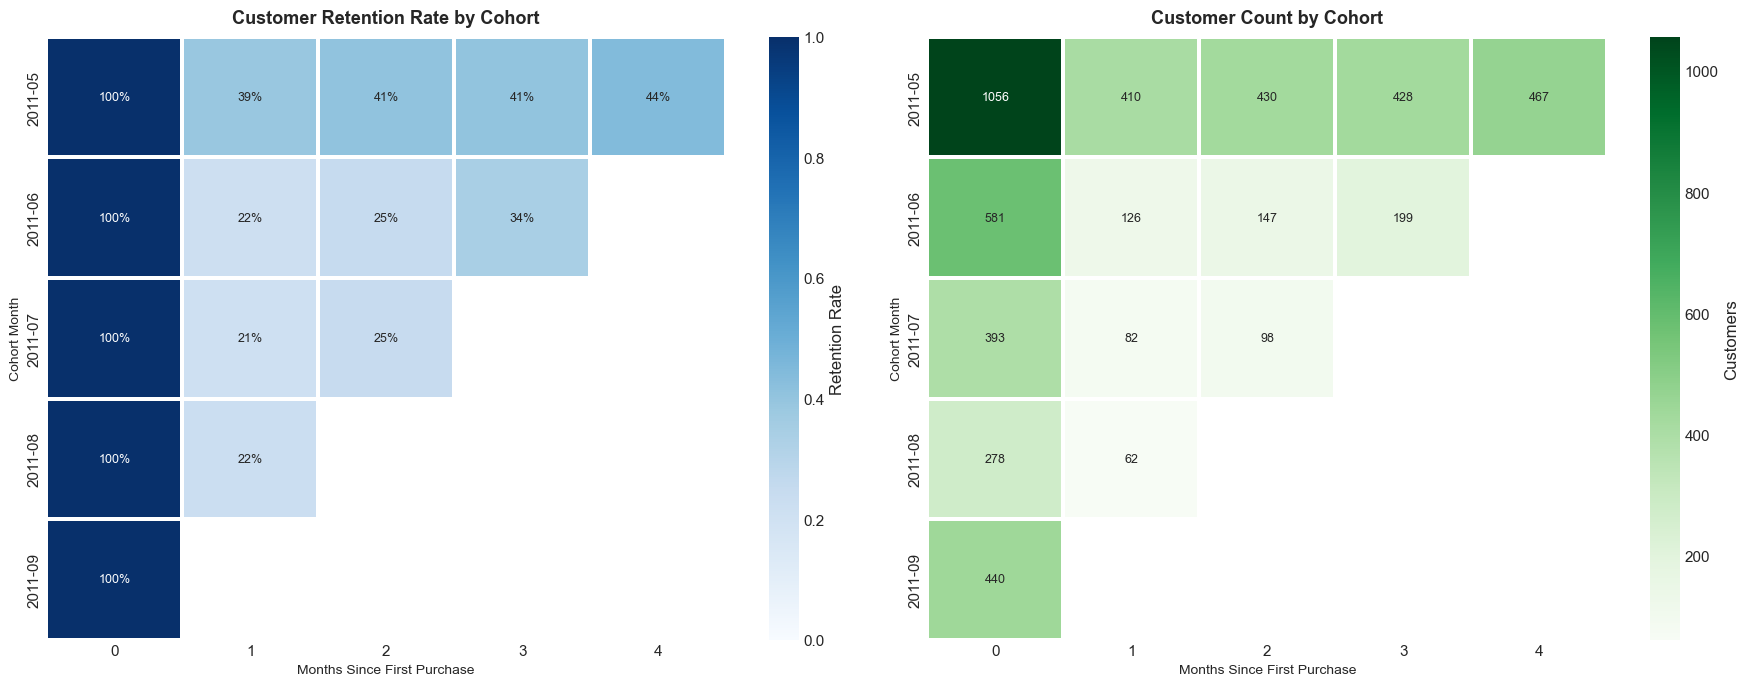

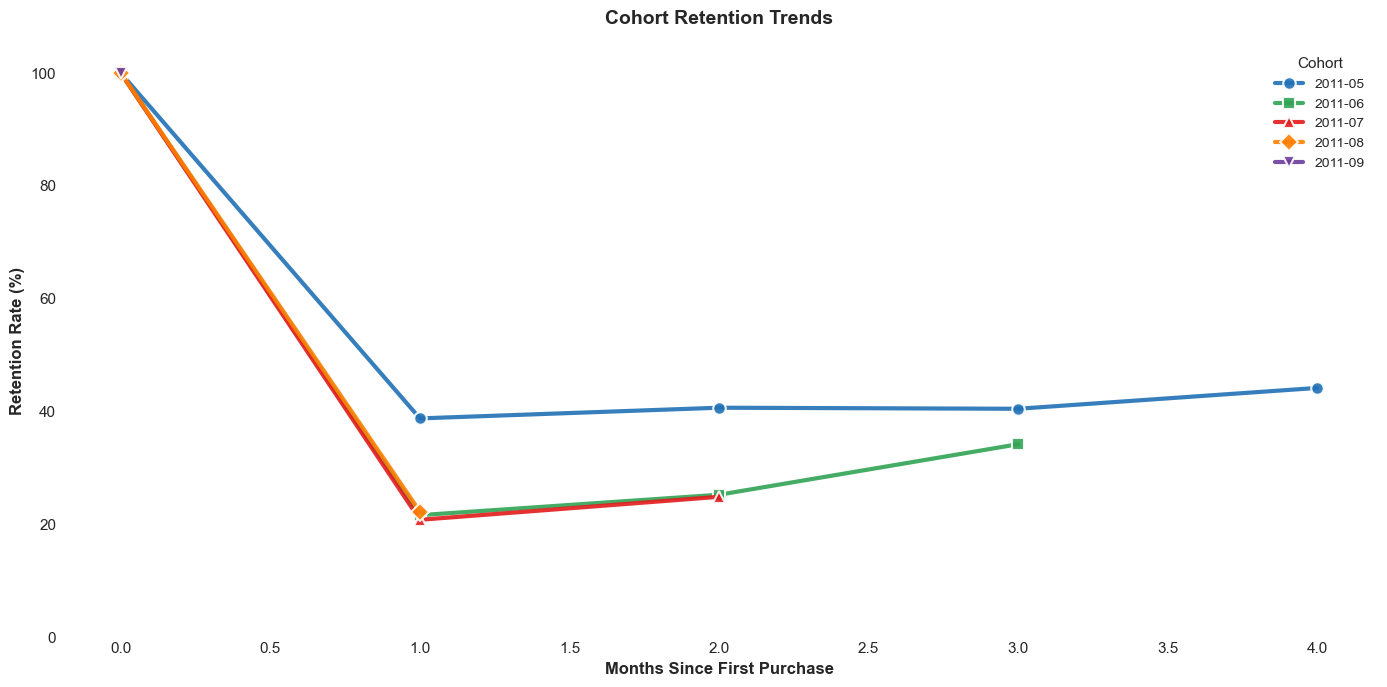


📊 RETENTION METRICS
Average 1-month retention: 25.92%
Average 3-month retention: 37.39%
Available retention periods: [1, 2, 3, 4] months


In [7]:
df['CohortMonth'] = (
    df.groupby('CustomerID')['InvoiceDate']
      .transform('min')
      .dt.to_period('M')
)

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

df['CohortIndex'] = (
    (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)
)
cohort = (
    df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
      .nunique()
      .reset_index()
)

cohort_pivot = cohort.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

cohort_retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)

# Cohort Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Retention Rate
sns.heatmap(
    cohort_retention,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    cbar_kws={'label': 'Retention Rate'},
    linewidths=1.5,
    linecolor='white',
    ax=ax1,
    vmin=0,
    vmax=1,
    annot_kws={'size': 9}
)
ax1.set_title('Customer Retention Rate by Cohort', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Months Since First Purchase', fontsize=10)
ax1.set_ylabel('Cohort Month', fontsize=10)

# Absolute Numbers
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    cbar_kws={'label': 'Customers'},
    linewidths=1.5,
    linecolor='white',
    ax=ax2,
    annot_kws={'size': 9}
)
ax2.set_title('Customer Count by Cohort', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Months Since First Purchase', fontsize=10)
ax2.set_ylabel('Cohort Month', fontsize=10)

plt.tight_layout()
plt.show()

# Retention Curves
fig, ax = plt.subplots(figsize=(14, 7))
cool_colors = ['#2171b5', '#31a354', '#e31a1c', '#ff7f00', '#6a3d9a']
markers = ['o', 's', '^', 'D', 'v']
linestyles = ['-', '-', '-', '-', '-']

for i, cohort_month in enumerate(cohort_retention.index[:6]):
    cohort_data = cohort_retention.loc[cohort_month].dropna()
    ax.plot(cohort_data.index, cohort_data.values * 100,
           marker=markers[i], linewidth=3, markersize=9,
           label=str(cohort_month), alpha=0.9, color=cool_colors[i],
           linestyle=linestyles[i], markeredgewidth=1.5, markeredgecolor='white')

ax.set_xlabel('Months Since First Purchase', fontsize=12, fontweight='bold')
ax.set_ylabel('Retention Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Cohort Retention Trends', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Cohort', fontsize=10, title_fontsize=11, loc='best', framealpha=0.95, 
         edgecolor='gray', fancybox=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print retention metrics for available months
print("\n📊 RETENTION METRICS")
available_months = cohort_retention.columns
if 1 in available_months:
    print(f"Average 1-month retention: {cohort_retention[1].mean()*100:.2f}%")
if 3 in available_months:
    print(f"Average 3-month retention: {cohort_retention[3].mean()*100:.2f}%")
if 6 in available_months:
    print(f"Average 6-month retention: {cohort_retention[6].mean()*100:.2f}%")
if 12 in available_months:
    print(f"Average 12-month retention: {cohort_retention[12].mean()*100:.2f}%")
print(f"Available retention periods: {sorted([int(x) for x in available_months if x != 0])} months")